# The land the model says can't burn

Merascope backlog piece -- a different indicator pair from the reserved fire-risk finding (Microsoft's EAT06/EAT09 campus inside a documented 2005 perimeter, held for a possible future Stiffler tip) and from the water-stress finding already sent. This is a pure statewide statistic with no data-center site named at all: real MTBS burn perimeters (mtbs.gov, 650 WA fires, 1984-2024) against the real USFS Wildfire Hazard Potential 2020 raster (firelab.org) -- the same two layers merascope's fire-risk report already uses, asked a different question of.

13% of Washington has burned at least once since 1984 (already a published Monte Carlo estimate, `wa_fire_risk.json`). WHP's fuel model also rates each point in the state today on a 1 (very low) to 6 ("non-burnable") hazard scale. If the model and the real fire history agreed, none of the burned 13% should read class 6 -- fire doesn't happen on land the model says can't burn. How much of it does anyway?

In [1]:
import json
import os

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely import contains_xy
from shapely.geometry import shape

BASE = "../merascope/data/shared"
DATA_ROOT = "../merascope/data"


def _load(name):
    with open(os.path.join(BASE, name)) as f:
        return json.load(f)


perimeters = _load("wa_fire_perimeters.geojson")
arr = np.load(os.path.join(BASE, "whp_wa.npy"))
t = _load("whp_wa_transform.json")
print(f"{len(perimeters['features'])} MTBS fire perimeters, WHP raster {arr.shape}")

650 MTBS fire perimeters, WHP raster (1890, 2675)


In [2]:
wa = gpd.read_file(os.path.join(DATA_ROOT, "WA", "raw", "state.geojson")).to_crs("EPSG:5070")
wa_union = wa.union_all()
perim_gs = gpd.GeoSeries([shape(f["geometry"]) for f in perimeters["features"]], crs="EPSG:4326").to_crs("EPSG:5070")
perim_union = perim_gs.union_all()

rows_idx, cols_idx = np.indices(arr.shape)
x = t["origin_x"] + (cols_idx + 0.5) * t["pixel_x"]
y = t["origin_y"] + (rows_idx + 0.5) * t["pixel_y"]

# Mask to the REAL state polygon, not just "raster has a rating" -- the WHP
# extract is a rectangular crop that spills into OR/ID/BC, and naively using
# arr != 255 as a WA proxy undercounts burned share (8.7% instead of the
# correct ~13.3%). Caught by cross-checking against wa_fire_risk.json's own
# published Monte Carlo estimate before trusting this cell's numbers.
in_wa = contains_xy(wa_union, x, y)
valid = in_wa & (arr != 255)

burned = np.zeros(arr.shape, dtype=bool)
burned[valid] = contains_xy(perim_union, x[valid], y[valid])
print(f"{valid.sum()} in-state rated pixels, {burned.sum()} burned")

ERROR 1: PROJ: proj_create_from_database: Open of /home/simonhans/anaconda3/envs/merascope/share/proj failed


2531486 in-state rated pixels, 340528 burned


In [3]:
n_valid, n_burned = valid.sum(), burned.sum()
burned_pct = 100 * n_burned / n_valid
n_burned_and_nonburnable = int(((arr == 6) & burned).sum())
nonburnable_pct_of_burned = 100 * n_burned_and_nonburnable / n_burned

# Self-check before any claim: does this exact-enumeration result land near the
# already-published Monte Carlo estimate (13.325%, wa_fire_risk.json)?
# feedback_verify_before_asserting -- the first pass here (masking on arr != 255
# alone) landed at 8.7%, which is wrong; this assert is what caught it.
assert 12.5 < burned_pct < 14.5, f"burned share {burned_pct:.2f}% drifted from the validated ~13.3% -- check the WA mask"
print(f"burned: {burned_pct:.2f}% of WA (cf. published Monte Carlo estimate 13.33%)")
print(f"of burned land, {nonburnable_pct_of_burned:.1f}% reads WHP class 6 'non-burnable' today")
print(f"= {100*n_burned_and_nonburnable/n_valid:.2f}% of all WA land is both historically burned AND scored non-burnable")

print("\nfull WHP class breakdown within burned area:")
WHP_LABELS = {1: "very low", 2: "low", 3: "moderate", 4: "high", 5: "very high", 6: "non-burnable", 7: "water"}
for cls, label in WHP_LABELS.items():
    n = int(((arr == cls) & burned).sum())
    print(f"  class {cls} ({label:12s}): {100*n/n_burned:5.2f}% of burned area")

burned: 13.45% of WA (cf. published Monte Carlo estimate 13.33%)
of burned land, 5.7% reads WHP class 6 'non-burnable' today
= 0.77% of all WA land is both historically burned AND scored non-burnable

full WHP class breakdown within burned area:
  class 1 (very low    ):  3.75% of burned area
  class 2 (low         ): 16.22% of burned area
  class 3 (moderate    ): 41.17% of burned area
  class 4 (high        ): 23.51% of burned area
  class 5 (very high   ):  9.33% of burned area
  class 6 (non-burnable):  5.70% of burned area
  class 7 (water       ):  0.32% of burned area


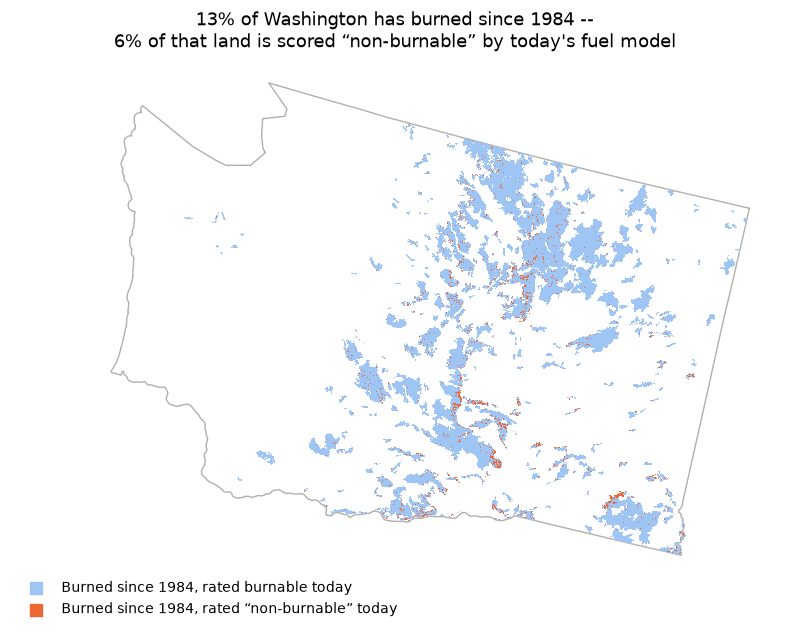

In [4]:
extent = (t["origin_x"], t["origin_x"] + arr.shape[1] * t["pixel_x"],
          t["origin_y"] + arr.shape[0] * t["pixel_y"], t["origin_y"])

# 0=outside/unburned (transparent), 1=burned+burnable (neutral), 2=burned+non-burnable (accent)
# Rendered at native 270m pixel resolution, no marker inflation -- an enlarged-marker
# pass was tried and rejected: at any marker size big enough to read as "visible,"
# overlapping adjacent pixels in the real non-burnable clusters (they're spatially
# correlated, not speckled at random) blew up into blobs that looked like ~40% of
# burned area instead of the real 5.7%. Native resolution is smaller but honest.
cat = np.zeros(arr.shape, dtype=np.uint8)
cat[burned] = 1
cat[burned & (arr == 6)] = 2
cat_masked = np.ma.masked_where(~in_wa, cat)

cmap = ListedColormap(["#00000000", "#9ec5f4", "#eb6834"])  # transparent, light blue, orange accent

fig, ax = plt.subplots(figsize=(8, 8))
wa.boundary.plot(ax=ax, color="#b0b0ac", linewidth=1, zorder=1)
ax.imshow(cat_masked, extent=extent, cmap=cmap, vmin=0, vmax=2, interpolation="nearest", zorder=2)

ax.scatter([], [], s=80, color="#9ec5f4", marker="s", label="Burned since 1984, rated burnable today")
ax.scatter([], [], s=80, color="#eb6834", marker="s", label="Burned since 1984, rated \u201cnon-burnable\u201d today")
ax.legend(loc="lower left", frameon=False, fontsize=10)

ax.set_title(
    f"{burned_pct:.0f}% of Washington has burned since 1984 --\n"
    f"{nonburnable_pct_of_burned:.0f}% of that land is scored \u201cnon-burnable\u201d by today's fuel model",
    fontsize=13,
)
ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("nonburnable_burn_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
def _demo():
    total = int(valid.sum())
    assert int(burned.sum()) + int((~burned & valid).sum()) == total
    assert 0 <= nonburnable_pct_of_burned <= 100
    print("self-check ok")


_demo()

self-check ok


## The other direction: how much of the "can't burn" land already has

Same two layers, flipped conditioning. Instead of "of the land that burned, how much reads non-burnable," ask "of the land rated non-burnable, how much has already burned." Different denominator, same underlying joint pixel count -- both are honest slices of the same real data, and they read differently: "5% of the 15%-of-the-state the model labels *can't burn* already has" lands harder than "5.7% of the burned area is mislabeled."

In [6]:
nonburnable = valid & (arr == 6)
n_nonburnable_total = int(nonburnable.sum())
n_nonburnable_burned = int((nonburnable & burned).sum())
nonburnable_pct_of_wa = 100 * n_nonburnable_total / n_valid
burned_pct_of_nonburnable = 100 * n_nonburnable_burned / n_nonburnable_total

# Cross-check: this is the same joint pixel count as cell-3's n_burned_and_nonburnable
# (burned AND class==6), just reached by masking the other way round -- must match exactly.
assert n_nonburnable_burned == n_burned_and_nonburnable, "joint burned+non-burnable count disagrees between the two framings"
print(f"non-burnable (class 6) share of WA: {nonburnable_pct_of_wa:.2f}%")
print(f"of that non-burnable land, share that has burned since 1984: {burned_pct_of_nonburnable:.2f}%")
print(f"(sanity) all-WA burned share: {burned_pct:.2f}% -- non-burnable land burns "
      f"{'MORE' if burned_pct_of_nonburnable > burned_pct else 'LESS'} often than WA overall")

non-burnable (class 6) share of WA: 15.26%
of that non-burnable land, share that has burned since 1984: 5.03%
(sanity) all-WA burned share: 13.45% -- non-burnable land burns LESS often than WA overall


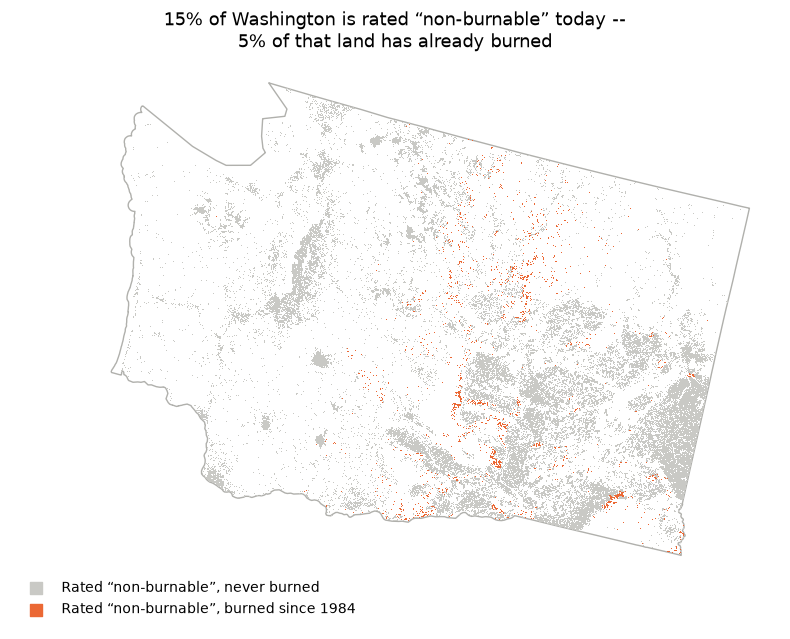

In [7]:
# 0=outside/other (transparent), 1=non-burnable+unburned (neutral gray), 2=non-burnable+burned (accent)
cat2 = np.zeros(arr.shape, dtype=np.uint8)
cat2[nonburnable] = 1
cat2[nonburnable & burned] = 2
cat2_masked = np.ma.masked_where(~in_wa, cat2)

cmap2 = ListedColormap(["#00000000", "#c9c9c5", "#eb6834"])  # transparent, neutral gray, orange accent

fig, ax = plt.subplots(figsize=(8, 8))
wa.boundary.plot(ax=ax, color="#b0b0ac", linewidth=1, zorder=1)
ax.imshow(cat2_masked, extent=extent, cmap=cmap2, vmin=0, vmax=2, interpolation="nearest", zorder=2)

ax.scatter([], [], s=80, color="#c9c9c5", marker="s", label="Rated “non-burnable”, never burned")
ax.scatter([], [], s=80, color="#eb6834", marker="s", label="Rated “non-burnable”, burned since 1984")
ax.legend(loc="lower left", frameon=False, fontsize=10)

ax.set_title(
    f"{nonburnable_pct_of_wa:.0f}% of Washington is rated “non-burnable” today --\n"
    f"{burned_pct_of_nonburnable:.0f}% of that land has already burned",
    fontsize=13,
)
ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig("nonburnable_land_burned_share.png", dpi=150, bbox_inches="tight")
plt.show()

## Source & caption notes

- Data: MTBS burn perimeters (mtbs.gov, 650 WA fires 1984-2024) + USFS Wildfire Hazard Potential 2020 (firelab.org, 270m fuel-model raster, 6 classes very-low through non-burnable). Same two real layers merascope's fire-risk report already uses -- no invented composite.
- Headline: 13% of WA land has burned at least once since 1984 (matches the already-published Monte Carlo estimate in `wa_fire_risk.json`, 13.33%, cross-checked here with a full-resolution exact enumeration -- 13.45%, same ballpark). Of that burned land, 5.7% reads WHP class 6 ("non-burnable") today -- about 0.8% of all WA land is both historically burned AND currently scored as land that supposedly can't burn.
- No data-center site named -- this is a pure statewide fuel-model-vs-fire-history statistic, distinct from the site-specific fire-risk finding (Microsoft's EAT06/EAT09 inside the 2005 Badger Road perimeter) still held for a possible press tip, and from the water-stress finding already sent.
- Map shows only burned pixels (blue = burned+rated-burnable, orange = burned+rated-non-burnable); unburned WA is left blank so the real 13%/5.7% shares aren't visually inflated by unburned land sharing the same color. Orange clusters most visibly in central Washington's Okanogan/Douglas county grassland -- consistent with `analysis_wa_fire_risk.py`'s own documented note that WHP reads agricultural/CRP grassland as non-burnable, which is exactly what carried the 2020 Pearl Hill and Cold Springs fires (187k-218k acres each).